# EuAl4 version Fit modes

In [12]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# Standard library
from importlib import reload
from time import time

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
import tensorflow as tf

# Local imports
import LD1_C1_alris_functions
reload(LD1_C1_alris_functions)
from LD1_C1_alris_functions import (
    transform_list_hkl_p63_p65,
    get_structure_factors,
    atom_position_list,
    get_structure_factors_CO,
)

# Set random seed for reproducibility
tf.keras.utils.set_random_seed(1)

# =============================================================================
# CONFIGURATION CONSTANTS
# =============================================================================
structure_type = 'C1'
irrep = 'LD1'
path = 'D:\\OneDrive\\PhD\\Projects\\2511HXRD\\Refinement\\' + irrep + '\\' + structure_type
sub_name = path + '\\' +irrep + '_' + structure_type
print(sub_name)

with open(sub_name + '_mario_mode_names.txt', 'r') as f:
    mode_num = sum(1 for line in f if line.strip())
print(f"mode_num: {mode_num}")
data_path = 'D:\\OneDrive\\PhD\\Projects\\2511HXRD\\Data Process\\table\\All Combined.csv'

# Normalization factor for intensity scaling
intensity_normalization = np.float32(26915.858751399992)
intensity_scale = 10000

# Debye-Waller factor
#w = tf.constant(0.0005560479314424701, dtype=tf.float32)
w = tf.constant(0.001, dtype=tf.float32)

# Mode normalization factors (constant across the analysis)
norm_factors = tf.constant(
    np.loadtxt(sub_name + '_norm_factors.txt', dtype=np.float32, delimiter=','),
    dtype=tf.float32
)

D:\OneDrive\PhD\Projects\2511HXRD\Refinement\LD1\C1\LD1_C1
mode_num: 48


Define the function containing the fitting parameters

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- `fun_tf()` correspond to the **structure factor calculation function** (one has to convert it to a **TF-compatible** function)
- <span style="color:red">If conversion to TF-compatible function is not possible, then this approach will probably not work (or becomes much more tedious at least)</span>

In [13]:
# =============================================================================
# HKL GRID GENERATION FUNCTIONS
# =============================================================================

def fn_all_hkl_list():
    """
    Generate the complete HKL grid for structure factor calculation.
    
    Returns:
        tf.Tensor: 3D tensor of shape (N, 3) containing all HKL coordinates
    """
    h_range = np.linspace(-10, 10, 21)
    k_range = np.linspace(-4, 4, 9)
    l_range = np.linspace(-10-1/6, 10 + 1/6, 123)
    
    hkl_grid = np.array(np.meshgrid(h_range, k_range, l_range)).T.reshape(-1, 3)
    return tf.convert_to_tensor(hkl_grid, dtype=tf.float32)

In [14]:
np.linspace(-10-1/6, 10 + 1/6, 123)


array([-10.16666667, -10.        ,  -9.83333333,  -9.66666667,
        -9.5       ,  -9.33333333,  -9.16666667,  -9.        ,
        -8.83333333,  -8.66666667,  -8.5       ,  -8.33333333,
        -8.16666667,  -8.        ,  -7.83333333,  -7.66666667,
        -7.5       ,  -7.33333333,  -7.16666667,  -7.        ,
        -6.83333333,  -6.66666667,  -6.5       ,  -6.33333333,
        -6.16666667,  -6.        ,  -5.83333333,  -5.66666667,
        -5.5       ,  -5.33333333,  -5.16666667,  -5.        ,
        -4.83333333,  -4.66666667,  -4.5       ,  -4.33333333,
        -4.16666667,  -4.        ,  -3.83333333,  -3.66666667,
        -3.5       ,  -3.33333333,  -3.16666667,  -3.        ,
        -2.83333333,  -2.66666667,  -2.5       ,  -2.33333333,
        -2.16666667,  -2.        ,  -1.83333333,  -1.66666667,
        -1.5       ,  -1.33333333,  -1.16666667,  -1.        ,
        -0.83333333,  -0.66666667,  -0.5       ,  -0.33333333,
        -0.16666667,   0.        ,   0.16666667,   0.33

In [15]:
def make_hkl_indices(hkl_list, experimental_data):
    """
    Map experimental HKL values to indices in the full HKL grid.
    
    Args:
        hkl_list: List of experimental HKL coordinates
        experimental_data: DataFrame with experimental intensities
        
    Returns:
        tuple: (hkl_indices tensor, reordered HKL list, corresponding intensities)
    """
    SCALE_FACTOR = 6
    
    # Scale HKL values to integers for matching
    hkl_scaled = pd.DataFrame(
        (np.array(hkl_list, dtype=np.float32) * SCALE_FACTOR).astype(int),
        columns=['h', 'k', 'l']
    )
    
    # Generate full HKL grid (scaled)
    h_range = (np.linspace(-10, 10, 21) * SCALE_FACTOR).astype(int)
    k_range = (np.linspace(-4, 4, 9) * SCALE_FACTOR).astype(int)
    l_range = np.round(np.linspace(-10-1/6, 10 + 1/6, 123)* SCALE_FACTOR).astype(int)
    
    full_hkl_grid = np.array(np.meshgrid(h_range, k_range, l_range)).T.reshape(-1, 3)
    full_hkl_df = pd.DataFrame(full_hkl_grid, columns=['h', 'k', 'l'])
    
    # Find matching indices
    merged = full_hkl_df.merge(hkl_scaled, how='left', indicator=True)
    matched_indices = merged[merged['_merge'] == 'both'].index.tolist()
    
    # Get reordered HKL values
    reordered_hkl = full_hkl_df.iloc[matched_indices].copy()
    
    # Scale experimental data for matching
    exp_data_scaled = experimental_data.copy()
    exp_data_scaled[['h', 'k', 'l']] = np.round(
        exp_data_scaled[['h', 'k', 'l']] * SCALE_FACTOR
    ).astype(int)
    
    # Extract intensities in the correct order
    intensities = []
    for _, row in reordered_hkl.iterrows():
        mask = (
            (exp_data_scaled['h'] == row['h']) &
            (exp_data_scaled['k'] == row['k']) &
            (exp_data_scaled['l'] == row['l'])
        )
        intensity_vals = exp_data_scaled.loc[mask, 'intensity_exp'].values
        intensities.append(intensity_vals[0] if len(intensity_vals) > 0 else 0)
    
    # Convert back to original scale
    reordered_hkl_array = reordered_hkl.values.astype(np.float32) / SCALE_FACTOR
    hkl_indices_tensor = tf.convert_to_tensor(matched_indices, dtype=tf.int32)
    
    print(f"Matched {len(matched_indices)} HKL points")
    
    return hkl_indices_tensor, reordered_hkl_array, intensities

In [16]:
# =============================================================================
# LOAD EXPERIMENTAL DATA
# =============================================================================

# Load raw experimental data
experimental_data2 = pd.read_csv(data_path)

#remove rows where h is greater than 9 or less than -9
#experimental_data2 = experimental_data2[(experimental_data2['h'] <= 4) & (experimental_data2['h'] >= -4)]


hkl_list = experimental_data2[["h", "k", "l"]].values.tolist()



# Compute HKL indices and reorder data
hkl_indices, hkl_list, intensity_reordered = make_hkl_indices(
    hkl_list, experimental_data2
)

# Create processed experimental DataFrame
experimental_data = pd.DataFrame(hkl_list, columns=['h', 'k', 'l'])
experimental_data['intensity_exp'] = intensity_reordered

# Convert to tensor
hkl_list = tf.convert_to_tensor(hkl_list, dtype=tf.float32)

# Load transformation matrix (kept for compatibility)
# path_matrix = f'{path}/C1_matrix.txt'
# matrix = tf.convert_to_tensor(np.loadtxt(path_matrix, dtype=np.float32), dtype=tf.float32)

Matched 4818 HKL points


Sample the "training data" (features and labels)

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The features are the (h,k,l) coordinates (e.g. a vector of size `n_features` x 3, i.e. `n_dim = 3`)
- Maybe one has to normalize the features (i.e. not using integers but floats between -1 (0) and 1)? Before passing them to the structure calculation function, they should be again rescaled to integers
- The labels would be the experimental intensities (again, maybe have to be normalized to the range between 0 and 1)

Number of features: 4818
Features shape: (4818, 3)
Labels shape: (4818, 1)
Labels range: [0.0000, 1.0000]
Error weights range: [1.000000, 34635156536823906979619830497280.000000]


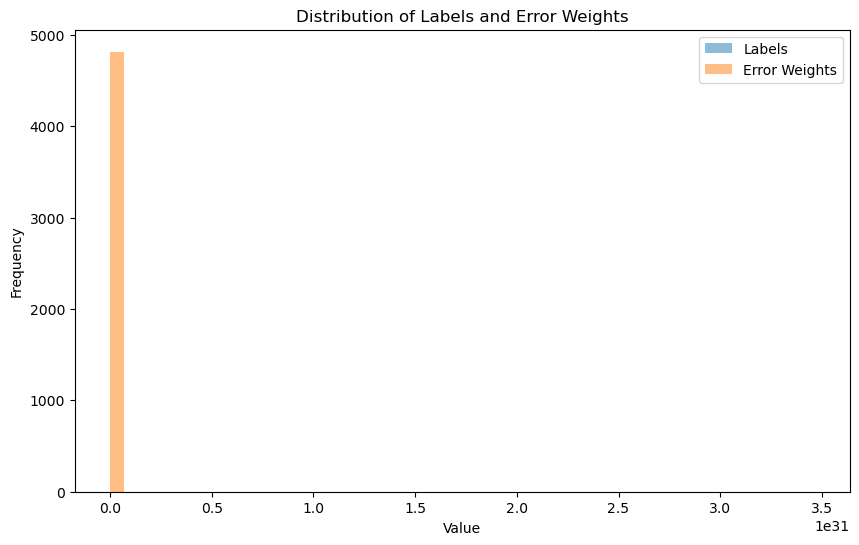

In [17]:
# =============================================================================
# PREPARE FEATURES AND LABELS
# =============================================================================

n_features = experimental_data.shape[0]
n_dim = 3

# Features are the HKL coordinates
features = hkl_list

# Normalize labels (intensities)
labels_raw = experimental_data["intensity_exp"].values
labels = labels_raw / intensity_normalization 
#labels = labels_raw / np.max(labels_raw)

# Compute error weights (inverse of intensity, with small value for zeros)
vol_err = np.where(
    labels == 0,
    1e-9,  # High error for zero labels
    1 / labels
)

# Convert to tensors with proper shape
labels = tf.convert_to_tensor(labels, dtype=tf.float32)
labels = tf.expand_dims(labels, axis=-1)

labels_err = tf.convert_to_tensor(vol_err, dtype=tf.float32)
labels_err = tf.expand_dims(labels_err, axis=-1)

# Print summary statistics
print(f"Number of features: {n_features}")
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Labels range: [{tf.reduce_min(labels):.4f}, {tf.reduce_max(labels):.4f}]")
print(f"Error weights range: [{tf.reduce_min(labels_err):.6f}, {tf.reduce_max(labels_err):.6f}]")

# Visualize label distributions
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(labels.numpy(), bins=50, alpha=0.5, label='Labels')
ax.hist(labels_err.numpy(), bins=50, alpha=0.5, label='Error Weights')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Labels and Error Weights')
ax.legend()
plt.show()

In [18]:
# =============================================================================
# STRUCTURE FACTOR CALCULATION
# =============================================================================

# Precompute the constant HKL grid (does not depend on model parameters)


_all_hkl_list_cached = transform_list_hkl_p63_p65(fn_all_hkl_list())

# Compute |Q| = 2π * sqrt((h² + k²)/a² + l²/c²) for EuAl4 tetragonal
# Note: _all_hkl_list_cached has l scaled by 6, so undo that
_a_lat = 4.402   # Å
_c_lat = 11.163  # Å
_h_cached = _all_hkl_list_cached[:, 0]
_k_cached = _all_hkl_list_cached[:, 1]
_l_cached = _all_hkl_list_cached[:, 2] / 6.0  # original l in r.l.u.
_qnorms_cached = 2 * np.pi * tf.sqrt((_h_cached**2 + _k_cached**2) / _a_lat**2 + _l_cached**2 / _c_lat**2)
_dw_factor_cached = tf.exp(-w * _qnorms_cached ** 2)
_base_struct = atom_position_list(*([0.0] * mode_num))  # Base structure for CO calculation

def fun_tf(hkl_list, pars, hkl_indices):
    """
    Compute structure factors with parameter-dependent atomic positions.
    
    Args:
        hkl_list: HKL coordinates tensor
        pars: Mode amplitude parameters
        matrix: Transformation matrix (kept for API compatibility)
        hkl_indices: Indices to select from full calculation
        
    Returns:
        tf.Tensor: Simulated intensities for the selected HKL points
    """
    # Apply normalization to parameters
    pars_tensor = tf.stack(pars) * norm_factors
    pars_tensor = tf.reshape(pars_tensor, (mode_num,))
    pars_list = tf.unstack(pars_tensor)
    
    # Compute atomic positions with current parameters
    modified_struct = atom_position_list(*pars_list)
    
    # Calculate structure factors and intensities using cached HKL grid
    sf_hkl = get_structure_factors(_all_hkl_list_cached, modified_struct)
    #sf_hkl = get_structure_factors_CO(_all_hkl_list_cached, modified_struct, _base_struct)
    intensity = tf.abs(sf_hkl) ** 2
    
    
    # Apply Debye-Waller correction (using cached values)
    intensity = intensity * _dw_factor_cached
    
    # Normalize intensities
    #all_sim_intensity = intensity / tf.reduce_sum(intensity) * intensity_scale
    
    all_sim_intensity = intensity / (tf.reduce_max(intensity) + 1e-12)
    
    # Extract intensities for experimental HKL points
    return tf.gather(all_sim_intensity, hkl_indices)

Define a simple model

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The six parameters (a,b,c,d,e,f) correspond to the fractional atomic shifts in the modes w.r.t. unit cell lengths
- Instead of `sigmoid`, `tanh` should be applied to the parameters before passing them to the structure factor calculation function (ensures smoother gradient landscape)
- The `tanh` function can furthermore be limited to a specific range (e.g. if atomic distortions should not exceed +- 0.1)

In [19]:
# =============================================================================
# MODEL DEFINITION
# =============================================================================

class FunAsLayer(tf.keras.layers.Layer):
    """
    Custom Keras layer that computes structure factors from learnable mode amplitudes.
    """
    
    def __init__(self, max_mode_amps, hkl_indices, **kwargs):
        super().__init__(**kwargs)
        self.max_mode_amps = max_mode_amps
        self.hkl_indices = hkl_indices

    def build(self, input_shape):
        """Initialize the trainable mode amplitude parameters."""
        self.param = self.add_weight(
            name='param',
            shape=(mode_num,),
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=2),
            trainable=True,
            constraint=lambda x: tf.clip_by_value(x, -self.max_mode_amps, self.max_mode_amps)
        )
        super().build(input_shape)

    def call(self, inputs):
        """Forward pass: compute structure factors from current parameters."""
        output = fun_tf(inputs, self.param, self.hkl_indices)
        return tf.reshape(output, [-1])

Create optimizer and define loss function

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The learning rate must be determined by experimentation (same holds for the batch size and the number of epochs below)
- As a loss function, one can try either MSE or R-score (MSE seems to be the more "natural choice" in this case)

In [20]:
# =============================================================================
# METRICS AND LOSS FUNCTIONS
# =============================================================================

# from matplotlib.pylab import reshape

_EPS = 1e-8  # Small constant to prevent sqrt(0) gradient explosion

def r_factor_metric(y_true, y_pred):
    """
    Compute the crystallographic R-factor.
    
    R = Σ|√I_obs - √I_calc| / Σ√I_obs
    
    Args:
        y_true: Observed intensities
        y_pred: Calculated intensities
        
    Returns:
        R-factor value
    """
    y_true_flat = tf.reshape(y_true, [-1])
    sqrt_true = tf.sqrt(tf.maximum(y_true_flat, _EPS))
    sqrt_pred = tf.sqrt(tf.maximum(y_pred, _EPS))
    
    return tf.reduce_sum(tf.abs(sqrt_true - sqrt_pred)) / tf.reduce_sum(sqrt_true)


class RFactorLoss(tf.keras.losses.Loss):
    def call(self, y_true, y_pred):
        y_true = tf.reshape(y_true, [-1])
        return tf.reduce_sum(tf.abs(tf.sqrt(tf.maximum(y_true, _EPS)) - tf.sqrt(tf.maximum(y_pred, _EPS)))) / tf.reduce_sum(tf.sqrt(tf.maximum(y_true, _EPS)))

Train the model for n iterations (to try different initial weights)

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The number of iterations defines the "starting position" $w_0$ of the gradient descent algorithm
- Because there are probably many local minima, changing $w_0$ allows the algorithm to find different minima and increases the chances of finding the global minima

In [21]:
# =============================================================================
# TRAINING CONFIGURATION
# =============================================================================

# Training hyperparameters
lr = [2e-3]
n_epochs = 1000
n_iter = 1  # Number of random restarts

# Load mode amplitude bounds
path_max_mode_amps = f'{sub_name}_max_bound_vectors.txt'
max_mode_amps = tf.convert_to_tensor(
    np.loadtxt(path_max_mode_amps, dtype=np.float32, delimiter=','),
    dtype=tf.float32
)


def create_model(max_mode_amps, hkl_indices):
    """Create a new model instance with fresh weights."""
    inputs = tf.keras.Input(shape=(n_dim,))
    outputs = FunAsLayer(max_mode_amps, hkl_indices)(inputs)
    return tf.keras.Model(inputs, outputs)


def train_single_run(model, optim, features, labels, labels_err, n_epochs):
    """
    Train the model for a single run.
    
    Returns:
        tuple: (history, final_pars)
    """
    model.compile(
        optimizer=optim,
        loss=RFactorLoss(),
        metrics=[r_factor_metric],
        run_eagerly=False
    )
    
    history = model.fit(
        x=features,
        y=labels,
        batch_size=features.shape[0],  # Full batch
        epochs=n_epochs,
        verbose=1,
        shuffle=False,  # Important: keep False for reproducibility
        # sample_weight=labels_err
    )
    
    final_pars = model.layers[-1].get_weights()[0]
    return history, final_pars


def plot_training_history(all_losses, all_rfs, learning_rate):
    """Plot loss and R-factor curves for all iterations."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    for i, loss_values in enumerate(all_losses):
        axes[0].plot(loss_values, label=f'Iteration {i+1}')
    axes[0].set_title(f'Loss vs Epochs (LR={learning_rate})')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True)
    
    # R-factor plot
    for i, rf_values in enumerate(all_rfs):
        axes[1].plot(rf_values, label=f'Iteration {i+1}')
    axes[1].set_title(f'R-factor vs Epochs (LR={learning_rate})')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('R-factor')
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()


Training with learning rate: 0.002

--- Iteration 1/1 ---
Epoch 1/1000
1/1 [==============================] - 3s 3s/step - loss: 0.6615 - r_factor_metric: 0.6615
Epoch 2/1000
1/1 [==============================] - 0s 10ms/step - loss: 0.6594 - r_factor_metric: 0.6594
Epoch 3/1000
1/1 [==============================] - 0s 7ms/step - loss: 0.6571 - r_factor_metric: 0.6571
Epoch 4/1000
1/1 [==============================] - 0s 7ms/step - loss: 0.6548 - r_factor_metric: 0.6548
Epoch 5/1000
1/1 [==============================] - 0s 7ms/step - loss: 0.6525 - r_factor_metric: 0.6525
Epoch 6/1000
1/1 [==============================] - 0s 7ms/step - loss: 0.6502 - r_factor_metric: 0.6502
Epoch 7/1000
1/1 [==============================] - 0s 7ms/step - loss: 0.6479 - r_factor_metric: 0.6479
Epoch 8/1000
1/1 [==============================] - 0s 7ms/step - loss: 0.6455 - r_factor_metric: 0.6455
Epoch 9/1000
1/1 [==============================] - 0s 8ms/step - loss: 0.6431 - r_factor_metric: 0.6

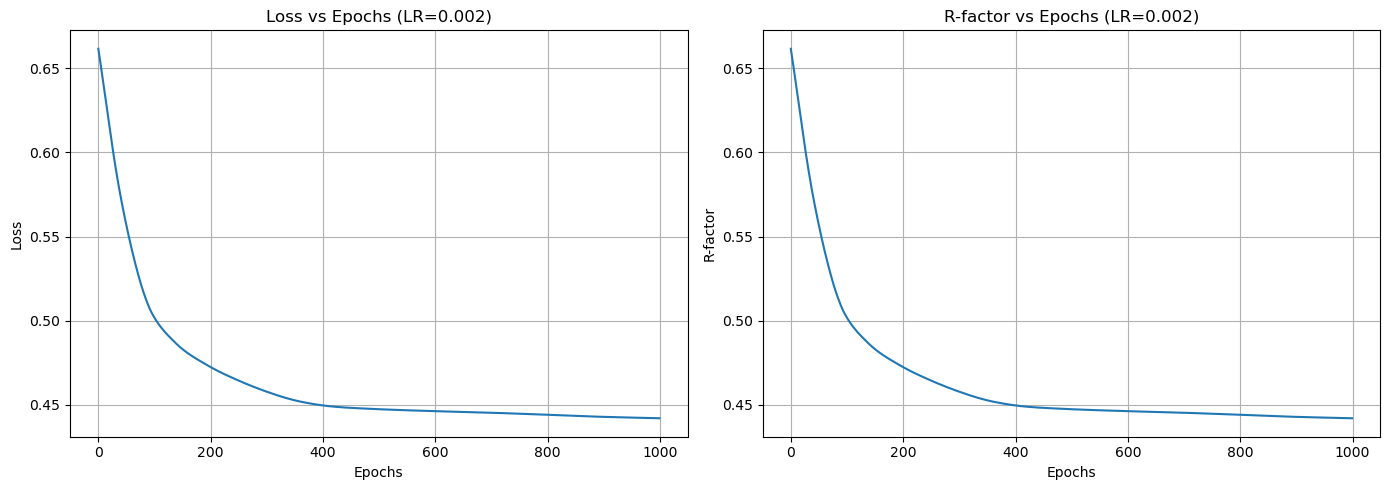

Best R-factor for LR=0.002: 4.421e-01


In [22]:
# =============================================================================
# TRAINING LOOP
# =============================================================================

# Track best results across all learning rates
best_pars_overall = None
best_rf_overall = np.inf
best_loss_overall = []

for learning_rate in lr:
    print(f"\n{'='*60}")
    print(f"Training with learning rate: {learning_rate}")
    print(f"{'='*60}")
    
    time_start = time()
    optim = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    # Track results for this learning rate
    all_losses = []
    all_rfs = []
    min_loss = np.inf
    best_model_pars = None
    
    for iteration in range(n_iter):
        print(f"\n--- Iteration {iteration + 1}/{n_iter} ---")
        
        # Create fresh model
        model = create_model(max_mode_amps, hkl_indices)
        initial_weights = model.layers[-1].get_weights()[0] * norm_factors.numpy()
        
        # Train
        history, current_params = train_single_run(
            model, optim, features, labels, labels_err, n_epochs
        )
        
        all_losses.append(history.history['loss'])
        all_rfs.append(history.history['r_factor_metric'])
        
        # Check if this is the best for current learning rate
        final_loss = history.history['loss'][-1]
        if final_loss < min_loss:
            min_loss = final_loss
            best_model_pars = current_params
            rf = r_factor_metric(labels, fun_tf(
                features, best_model_pars, hkl_indices
            ))
            print(f"New best: loss={min_loss:.3e}, R-factor={rf:.3e}")
    
    # Update overall best
    if min_loss < best_rf_overall:
        best_rf_overall = min_loss
        best_pars_overall = best_model_pars
        best_loss_overall = all_losses
    
    # Print timing info
    elapsed = time() - time_start
    print(f"\nTime elapsed: {elapsed:.2f}s")
    print(f"Iterations/second: {n_epochs * n_iter / elapsed:.1f}")
    
    # Plot training curves
    plot_training_history(all_losses, all_rfs, learning_rate)
    
    # Final evaluation
    final_weights = model.layers[-1].get_weights()[0] * norm_factors.numpy()
    y_pred = fun_tf(features, best_model_pars, hkl_indices)
    rf = r_factor_metric(labels, y_pred)
    print(f"Best R-factor for LR={learning_rate}: {rf:.3e}")

In [23]:
# =============================================================================
# BEST MODEL SUMMARY
# =============================================================================

print(f"Best overall loss: {best_rf_overall:.3e}")
print(f"Best R-factor: {r_factor_metric(labels, fun_tf(features, best_pars_overall, hkl_indices)):.3e}")

Best overall loss: 4.421e-01
Best R-factor: 4.421e-01


Best model parameters:
--------------------------------------------------
Mode a 1 I4/mmm[0,0,1/6]LD1(a,b)[Eu0:a:dsp]A2u(a): -0.168439
Mode a 2 I4/mmm[0,0,1/6]LD1(a,b)[Eu0:a:dsp]A2u(b): -0.172200
Mode a 3 I4/mmm[0,0,0]GM3-(a)[Eu0:a:dsp]A2u(a): -0.033256
Mode a 4 I4/mmm[0,0,1/3]LD1(a,b)[Eu0:a:dsp]A2u(a): -0.083997
Mode a 5 I4/mmm[0,0,1/3]LD1(a,b)[Eu0:a:dsp]A2u(b): -0.079751
Mode a 6 I4/mmm[0,0,1/2]LD1(a,b)[Eu0:a:dsp]A2u(a): -0.128673
Mode a 7 I4/mmm[0,0,1/2]LD1(a,b)[Eu0:a:dsp]A2u(b): -0.030878
Mode a 8 I4/mmm[0,0,2/3]LD1(a,b)[Eu0:a:dsp]A2u(a): -0.107109
Mode a 9 I4/mmm[0,0,2/3]LD1(a,b)[Eu0:a:dsp]A2u(b): +0.123728
Mode a10 I4/mmm[0,0,5/6]LD1(a,b)[Eu0:a:dsp]A2u(a): -0.037797
Mode a11 I4/mmm[0,0,5/6]LD1(a,b)[Eu0:a:dsp]A2u(b): +0.048574
Mode a12 I4/mmm[1,1,1]M3-(a)[Eu0:a:dsp]A2u(a): +0.041591
Mode a13 I4/mmm[0,0,1/6]LD1(a,b)[Al1:e:dsp]A1_1(a): -0.045723
Mode a14 I4/mmm[0,0,1/6]LD1(a,b)[Al1:e:dsp]A1_1(b): +0.025769
Mode a15 I4/mmm[0,0,1/6]LD1(a,b)[Al1:e:dsp]A1_2(a): -0.010594
Mode a16 I4/mmm

C:\Users\Administrator\AppData\Local\Temp\ipykernel_35900\2719088101.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


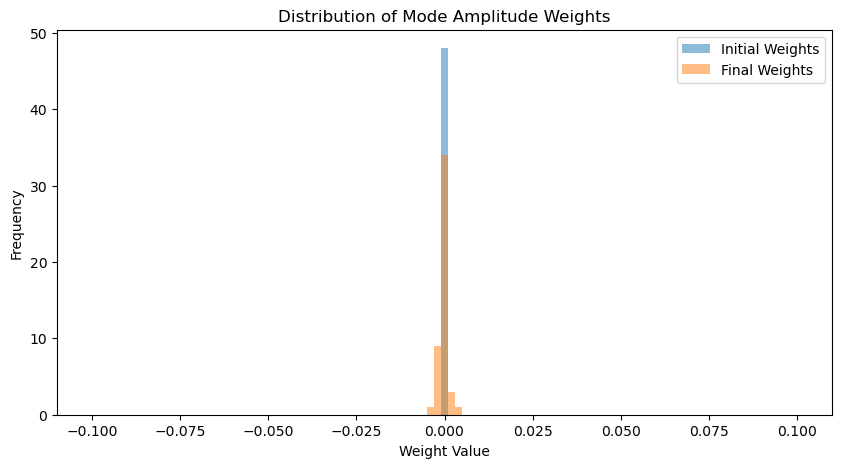

In [24]:
# =============================================================================
# ANALYZE MODE AMPLITUDES
# =============================================================================

# Load mode names
path_displacive_modes = f'{sub_name}_displacive_modes.txt'
mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)

# Print best model parameters
print("Best model parameters:")
print("-" * 50)
for i, par in enumerate(best_pars_overall):
    mode_name = mode_names.iloc[i, 1]
    normalized_amp = par / max_mode_amps[i]
    print(f"Mode a{i+1:2d} {mode_name:20s}: {normalized_amp:+.6f}")

# Find smallest non-zero mode amplitude
nonzero_mask = best_pars_overall != 0
if np.any(nonzero_mask):
    nonzero_amps = np.abs(best_pars_overall[nonzero_mask])
    smallest_amp = np.min(nonzero_amps)
    smallest_idx = np.where(np.abs(best_pars_overall) == smallest_amp)[0][0]
    print(f"\nSmallest non-zero amplitude: {smallest_amp:.8f}")
    print(f"Mode: a{smallest_idx + 1} {mode_names.iloc[smallest_idx, 1]}")

# Plot weight distributions
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(-0.1, 0.1, 100)
ax.hist(initial_weights, bins=bins, alpha=0.5, label='Initial Weights')
ax.hist(final_weights, bins=bins, alpha=0.5, label='Final Weights')
ax.set_xlabel('Weight Value')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Mode Amplitude Weights')
ax.legend()
plt.show()

In [ ]:
# =============================================================================
# SAVE BEST MODEL PARAMETERS
# =============================================================================

from save_best_model_parameters import save_best_model_parameters

# Change this path before running this cell.
output_csv_path = r"C:\Users\devou\OneDrive\Desktop\CRIS\ISOVIZ_INPUT\input_files\best_model_parameters.csv"

save_best_model_parameters(
    best_parameters=best_pars_overall,
    mode_names=mode_names,
    max_mode_amps=max_mode_amps,
    output_path=output_csv_path,
)

NameError: best_pars_overall is not defined. Please run the training cells above first and make sure the optimization completes before saving the results.

In [25]:
# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def alris_r_factor(data):
    """Calculate crystallographic R-factor from DataFrame."""
    exp_intensity = data['normalised_exp']
    sim_intensity = data['intensity_sim']
    return np.sum(np.abs(np.sqrt(exp_intensity) - np.sqrt(sim_intensity))) / np.sum(np.sqrt(exp_intensity))


def plot_plane_sim_vs_exp_DIM3_CO(ax, df, r_factor, h_value, use_log=True):
    """
    Plot simulated vs experimental intensities for a specific H plane.
    
    Args:
        ax: Matplotlib axis
        df: DataFrame with columns 'h', 'k', 'l', 'intensity_sim', 'normalised_exp'
        r_factor: R-factor value for the title
        h_value: H value to filter
        use_log: Whether to use log scaling for marker size
    """
    plane_data = df[df['h'] == h_value].copy()

    #remove rows where k and l are integer
    plane_data = plane_data[~((plane_data['k'] % 1 == 0) & (plane_data['l'] % 1 == 0))]
    
    if use_log:
        size_sim = np.log10(plane_data['intensity_sim'] + 1) * 100000
        size_exp = np.log10(plane_data['normalised_exp'] + 1) * 100000
    else:
        size_sim = plane_data['intensity_sim'] * 100
        size_exp = plane_data['normalised_exp'] * 100
    
    # Plot simulated (left half) and experimental (right half) as split circles
    ax.scatter(
        plane_data['k'], plane_data['l'],
        s=size_sim, c='red', edgecolor='black',
        marker=MarkerStyle("o", fillstyle="left"),
        label='Simulated'
    )
    ax.scatter(
        plane_data['k'], plane_data['l'],
        s=size_exp, c='blue', edgecolor='black',
        marker=MarkerStyle("o", fillstyle="right"),
        label='Experimental'
    )
    
    ax.set_xlabel(f'k in ({h_value}, k, l) [r.l.u.]')
    ax.set_ylabel(f'l in ({h_value}, k, l) [r.l.u.]')
    ax.set_title(f'H = {h_value} (log scale), R = {r_factor:.3f}')
    ax.legend()


def plot_plane_sim_vs_exp_DIM3_bragg(ax, df, r_factor, h_value, use_log=True):
    """
    Plot simulated vs experimental intensities for a specific H plane.
    
    Args:
        ax: Matplotlib axis
        df: DataFrame with columns 'h', 'k', 'l', 'intensity_sim', 'normalised_exp'
        r_factor: R-factor value for the title
        h_value: H value to filter
        use_log: Whether to use log scaling for marker size
    """
    plane_data = df[df['h'] == h_value].copy()
    plane_data = plane_data[((plane_data['k'] % 1 == 0) & (plane_data['l'] % 1 == 0))]

    
    if use_log:
        size_sim = np.log10(plane_data['intensity_sim'] + 1) * 10000
        size_exp = np.log10(plane_data['normalised_exp'] + 1) * 10000
    else:
        size_sim = plane_data['intensity_sim'] * 100
        size_exp = plane_data['normalised_exp'] * 100
    
    # Plot simulated (left half) and experimental (right half) as split circles
    ax.scatter(
        plane_data['k'], plane_data['l'],
        s=size_sim, c='red', edgecolor='black',
        marker=MarkerStyle("o", fillstyle="left"),
        label='Simulated'
    )
    ax.scatter(
        plane_data['k'], plane_data['l'],
        s=size_exp, c='blue', edgecolor='black',
        marker=MarkerStyle("o", fillstyle="right"),
        label='Experimental'
    )
    
    ax.set_xlabel(f'k in ({h_value}, k, l) [r.l.u.]')
    ax.set_ylabel(f'l in ({h_value}, k, l) [r.l.u.]')
    ax.set_title(f'H = {h_value} (log scale), R = {r_factor:.3f}')
    ax.legend()

Final R-factor: 0.442


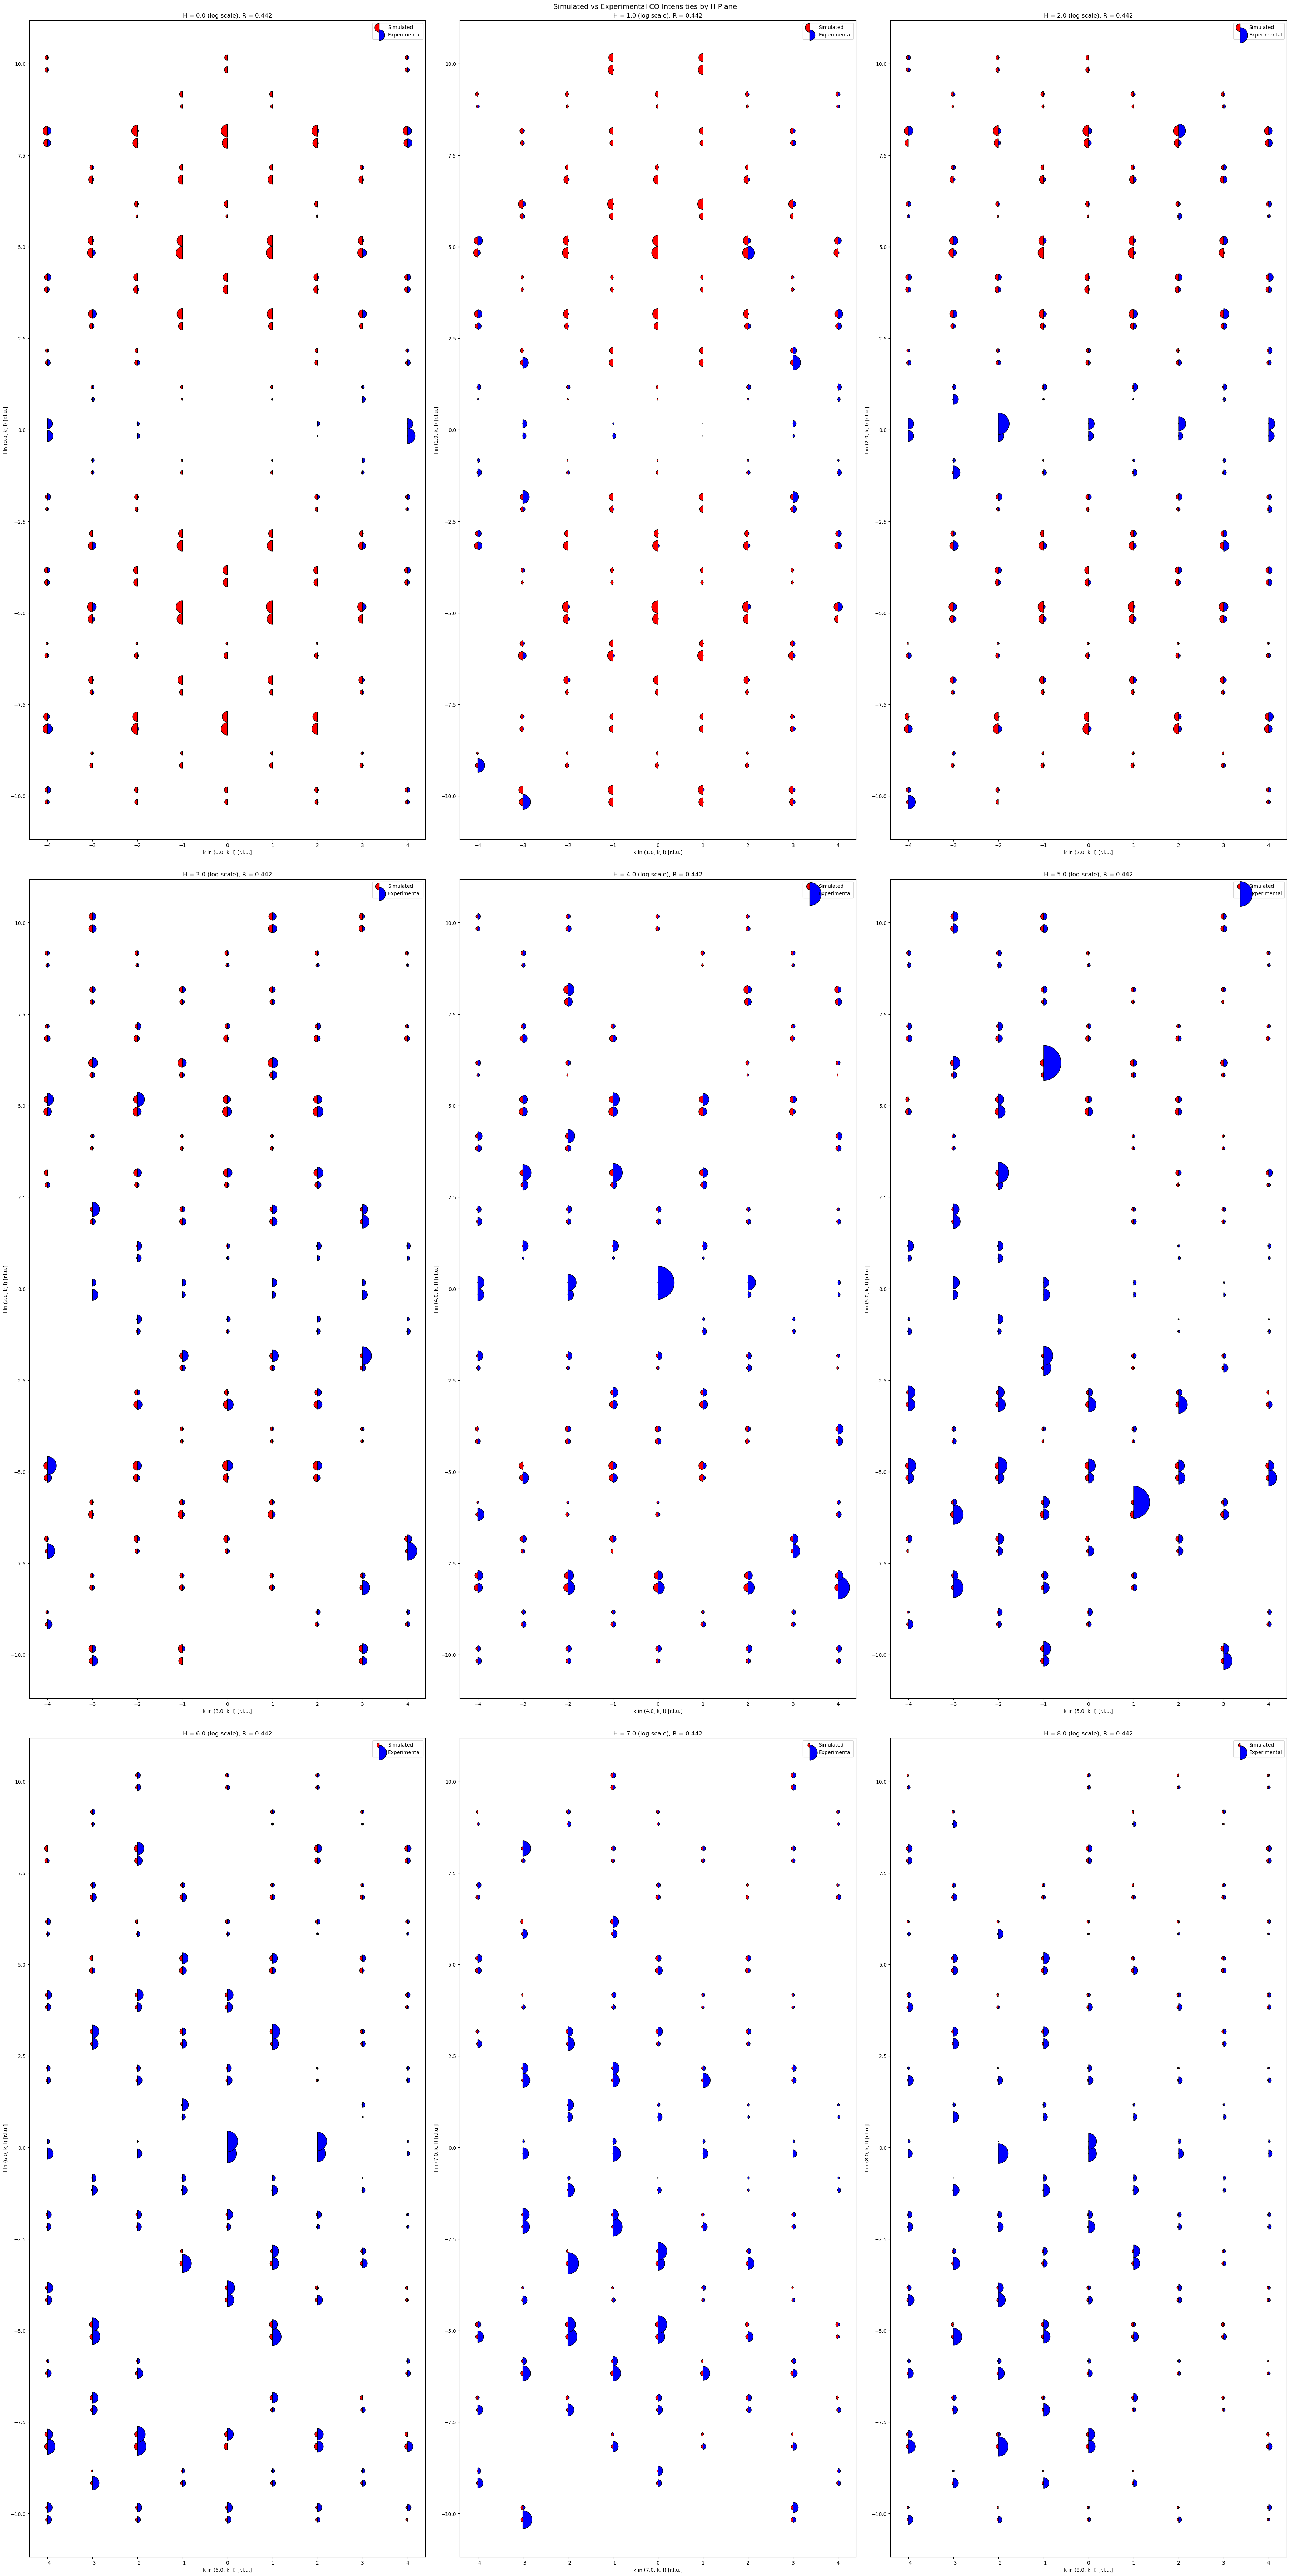

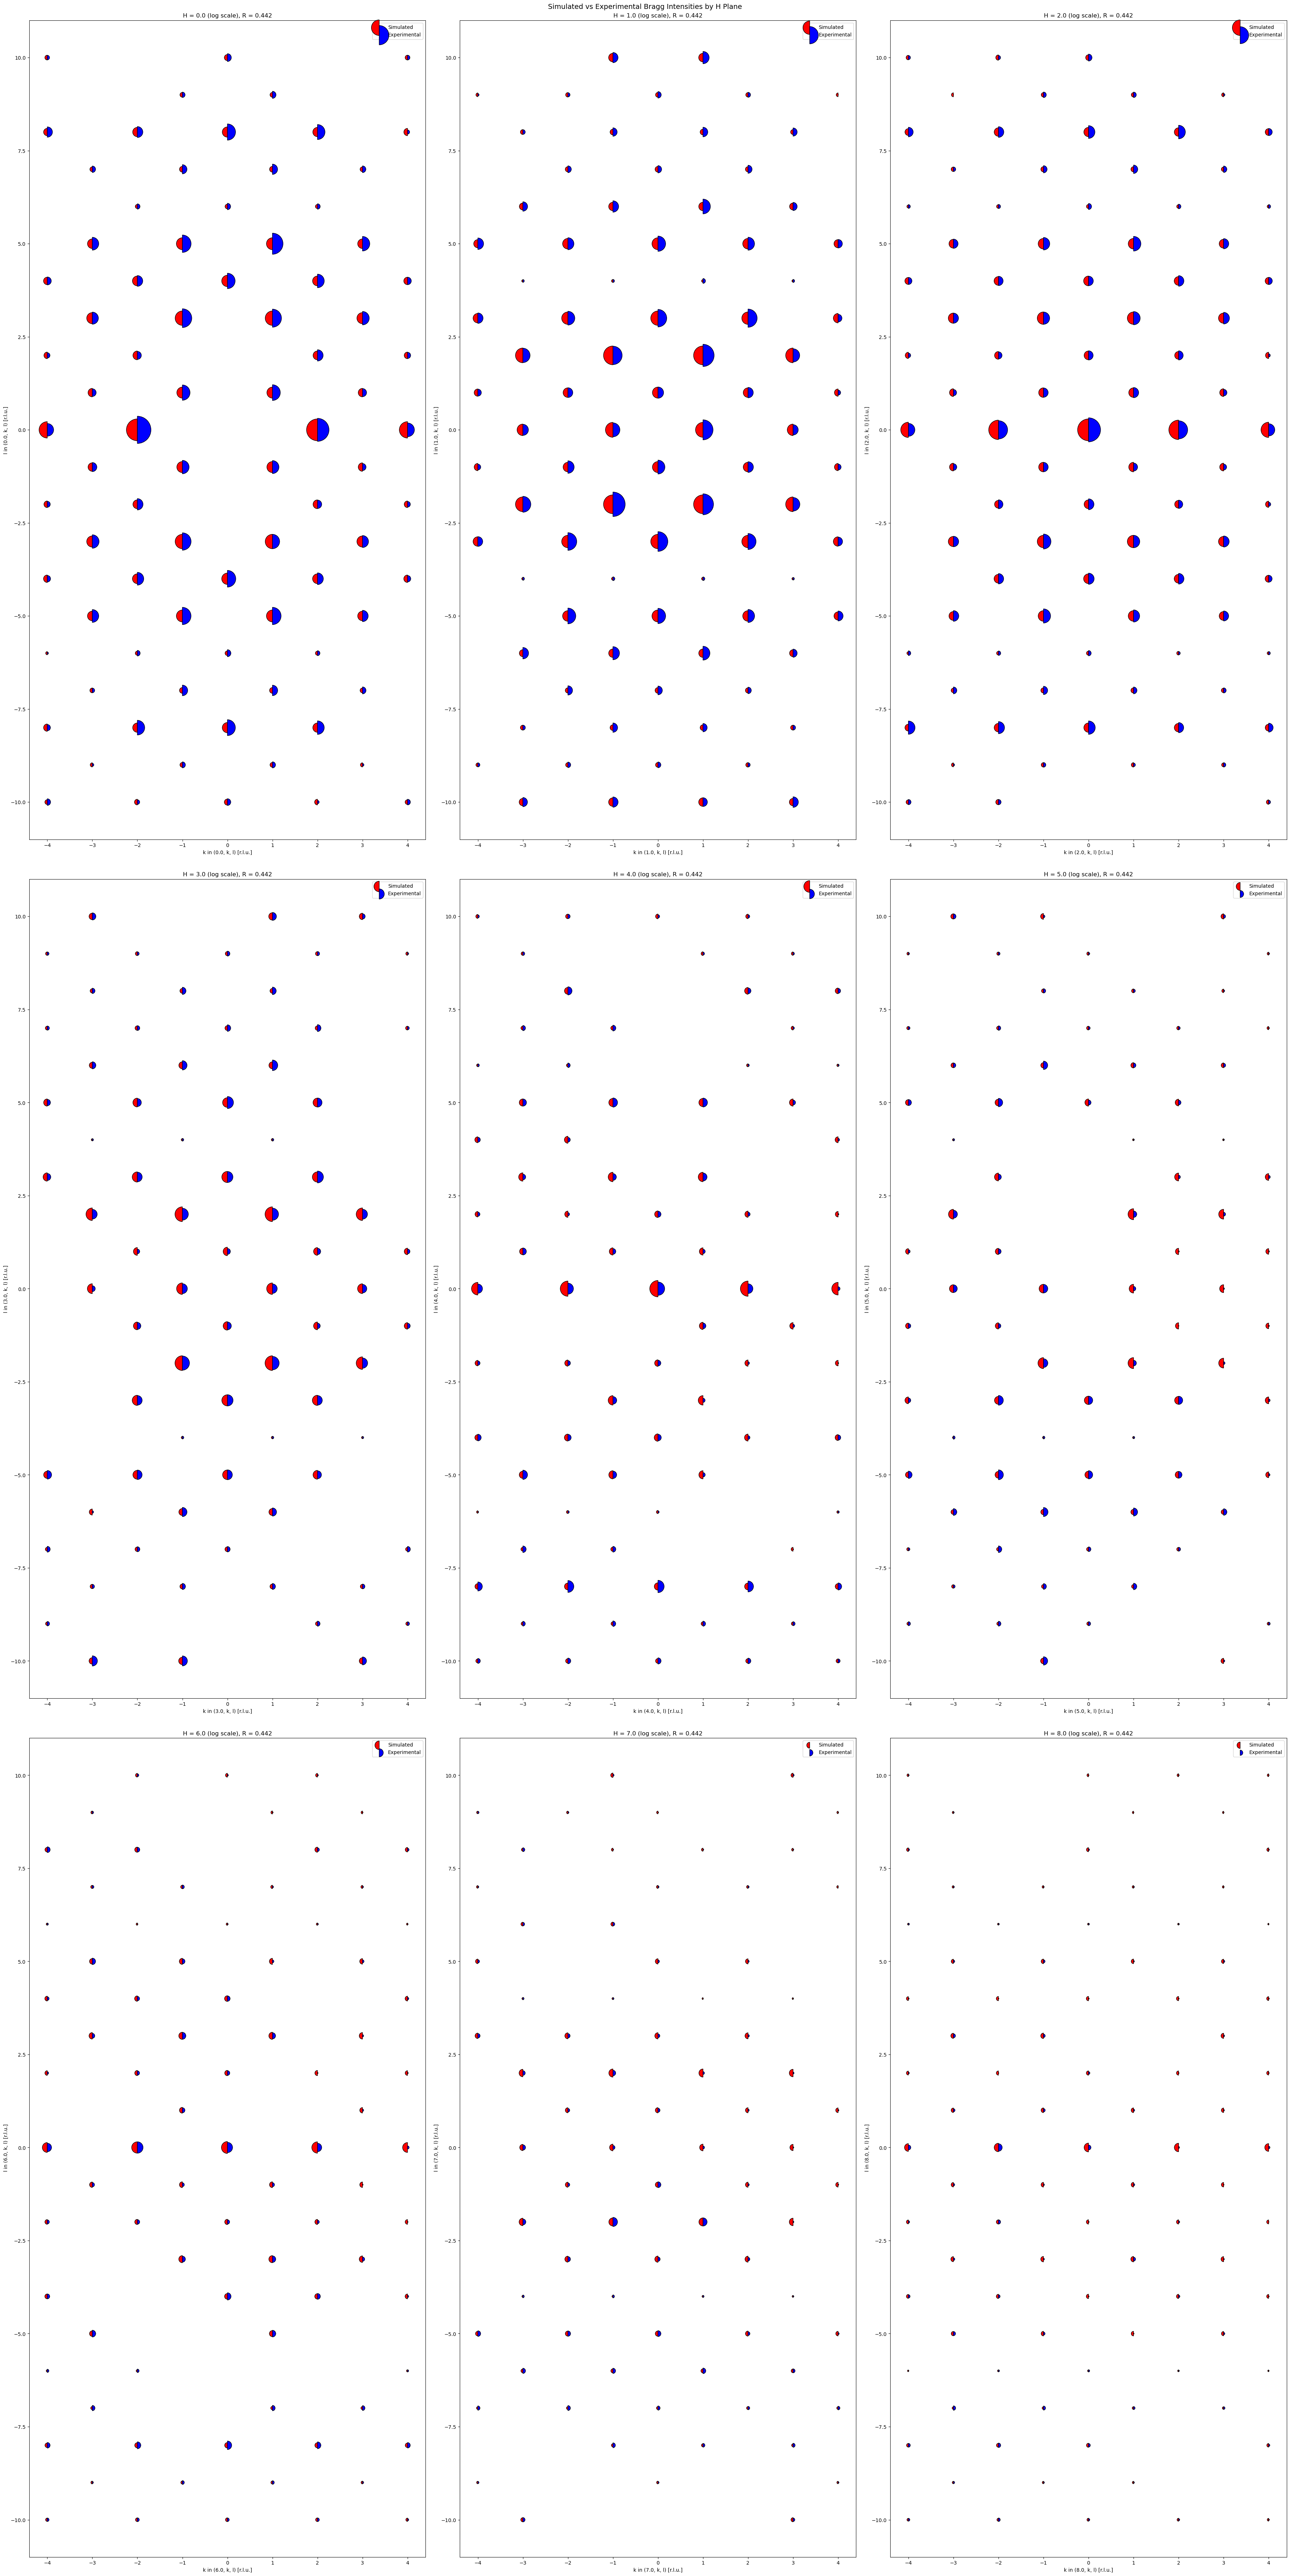

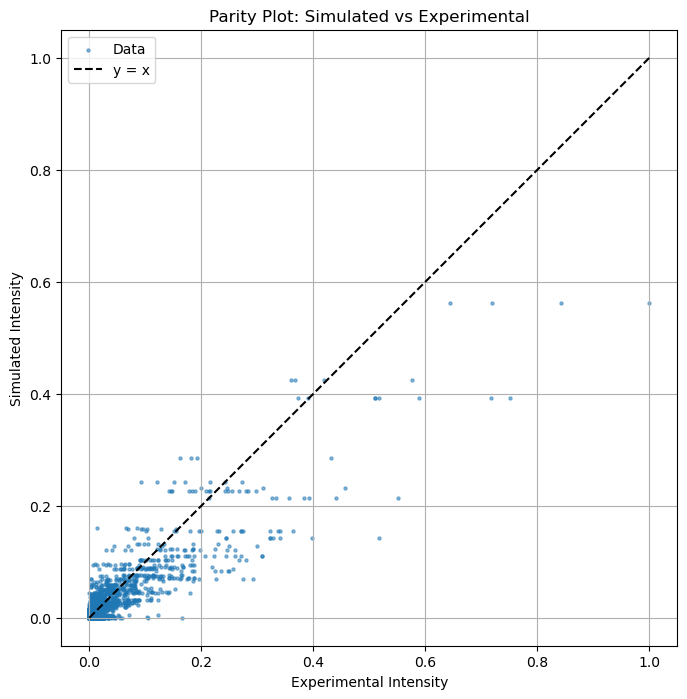

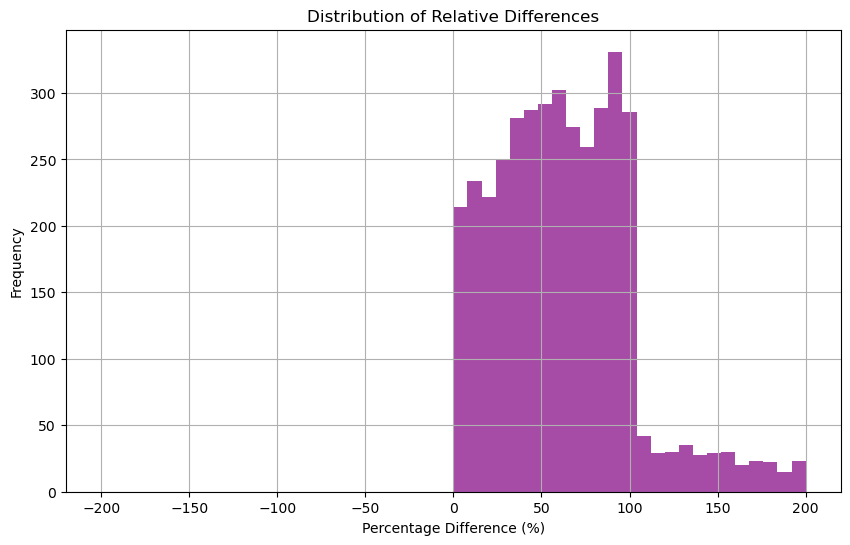

In [26]:
# =============================================================================
# FINAL RESULTS AND VISUALIZATION
# =============================================================================

# Prepare results DataFrame
exp_data = experimental_data.copy()
exp_data['intensity_sim'] = fun_tf(
    features, best_pars_overall, hkl_indices
).numpy()

# Normalize experimental data (using different normalization for visualization)
normalised_exp_data = exp_data['intensity_exp'] / intensity_normalization 
#normalised_exp_data = exp_data['intensity_exp'] / np.max(exp_data['intensity_exp']) 
exp_data['normalised_exp'] = normalised_exp_data
exp_data['intensity_exp_err'] = labels_err.numpy().flatten()

# Calculate final R-factor
r_factor = alris_r_factor(exp_data)
print(f"Final R-factor: {r_factor:.3f}")

# Plot HK planes for all H values
h_values = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
n_plots = len(h_values)
n_cols = int(np.ceil(n_plots / 3))

fig, axes = plt.subplots(3, n_cols, figsize=(12 * n_cols, 72), constrained_layout=True)
axes = axes.flatten()

for i, h in enumerate(h_values):
    plot_plane_sim_vs_exp_DIM3_CO(axes[i], exp_data, r_factor, h)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Simulated vs Experimental CO Intensities by H Plane', fontsize=14)
plt.show()


fig, axes = plt.subplots(3, n_cols, figsize=(12 * n_cols, 72), constrained_layout=True)
axes = axes.flatten()

for i, h in enumerate(h_values):
    plot_plane_sim_vs_exp_DIM3_bragg(axes[i], exp_data, r_factor, h)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Simulated vs Experimental Bragg Intensities by H Plane', fontsize=14)
plt.show()

# Parity plot (simulated vs experimental)
fig, ax = plt.subplots(figsize=(8, 8))

normalised_exp = normalised_exp_data
max_val = max(normalised_exp.max(), exp_data['intensity_sim'].max())
ax.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5, label='Data')
ax.plot([0, max_val], [0, max_val], 'k--', label='y = x')
ax.set_xlabel('Experimental Intensity')
ax.set_ylabel('Simulated Intensity')
ax.set_title('Parity Plot: Simulated vs Experimental')
ax.legend()
ax.grid(True)
ax.set_aspect('equal')
plt.show()

# Histogram of percentage differences
percentage_diff = np.abs(
    normalised_exp - exp_data['intensity_sim']
) / (normalised_exp + 1e-10) * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(percentage_diff, bins=50, range=(-200, 200), alpha=0.7, color='purple')
ax.set_xlabel('Percentage Difference (%)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Relative Differences')
ax.grid(True)
plt.show()

# Store percentage difference in results
exp_data['percentage_diff'] = percentage_diff